In [1]:
import scanpy as sc

In [2]:
def preprocess_sc(adata, batch_key='sample', min_genes=200, min_cells=50):
    '''
    preprocess single-cell rna sequencing data

    Args:
        adata: AnnData object
        batch_key: str, batch key
        min_genes: int, minimum number of genes expressed required for a cell to pass filtering
        min_cells: int, minimum number of cells expressed required for a gene to pass filtering

    Returns:
        adata: AnnData object, preprocessed adata

    '''
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_genes(adata, min_cells=min_cells)

    adata.layers['counts'] = adata.X.copy()
    sc.pp.normalize_total(adata, exclude_highly_expressed=True)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key=batch_key)
    sc.pp.pca(adata)

    return adata

In [3]:
data_file = './outs/adata/concatenated.h5ad'
out_dir = './outs/adata/'

Load Data

In [4]:
adata = sc.read_h5ad(data_file)
adata_small = adata[adata.obs['dataset'] == 'new'].copy()
print('adata:', adata)
print('adata_small:', adata_small)

adata: AnnData object with n_obs × n_vars = 232621 × 32627
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'sample', 'dataset'
    var: 'gene_ids', 'gene_names', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
adata_small: AnnData object with n_obs × n_vars = 128362 × 32627
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'dou

Preprocess

In [5]:
# preprocess
adata = preprocess_sc(adata)
adata_small = preprocess_sc(adata_small)

In [6]:
adata_unintegrated = adata.copy()
adata_harmony = adata.copy()
adata_bbknn = adata.copy()
adata_small_unintegrated = adata_small.copy()
adata_small_harmony = adata_small.copy()
adata_small_bbknn = adata_small.copy()

Integrate

In [7]:
# integrate
sc.external.pp.harmony_integrate(adata_harmony, key='sample')
sc.external.pp.bbknn(adata_bbknn, batch_key='sample')
sc.external.pp.harmony_integrate(adata_small_harmony, key='sample')
sc.external.pp.bbknn(adata_small_bbknn, batch_key='sample')

2024-11-22 23:25:55,804 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2024-11-22 23:26:06,906 - harmonypy - INFO - sklearn.KMeans initialization complete.


2024-11-22 23:26:07,825 - harmonypy - INFO - Iteration 1 of 10


2024-11-22 23:27:26,585 - harmonypy - INFO - Iteration 2 of 10


2024-11-22 23:28:44,399 - harmonypy - INFO - Iteration 3 of 10


...

2024-11-22 23:34:11,560 - harmonypy - INFO - sklearn.KMeans initialization complete.


2024-11-22 23:34:12,048 - harmonypy - INFO - Iteration 1 of 10


2024-11-22 23:34:43,254 - harmonypy - INFO - Iteration 2 of 10


2024-11-22 23:35:14,445 - harmonypy - INFO - Iteration 3 of 10


2024-11-22 23:35:45,903 - harmonypy - INFO - Converged after 3 iterations


View Batch Effect

In [8]:
sc.pp.neighbors(adata_unintegrated, use_rep='X_pca')
sc.tl.umap(adata_unintegrated)
sc.pp.neighbors(adata_harmony, use_rep='X_pca_harmony')
sc.tl.umap(adata_harmony)
sc.tl.umap(adata_bbknn)
sc.pp.neighbors(adata_small_unintegrated, use_rep='X_pca')
sc.tl.umap(adata_small_unintegrated)
sc.pp.neighbors(adata_small_harmony, use_rep='X_pca_harmony')
sc.tl.umap(adata_small_harmony)
sc.tl.umap(adata_small_bbknn)

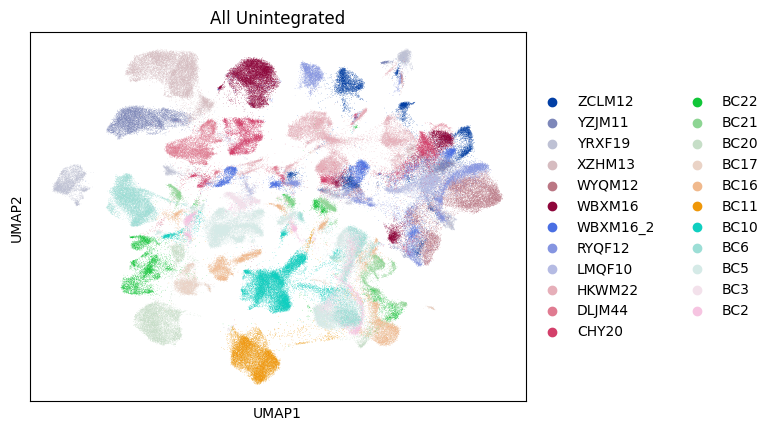

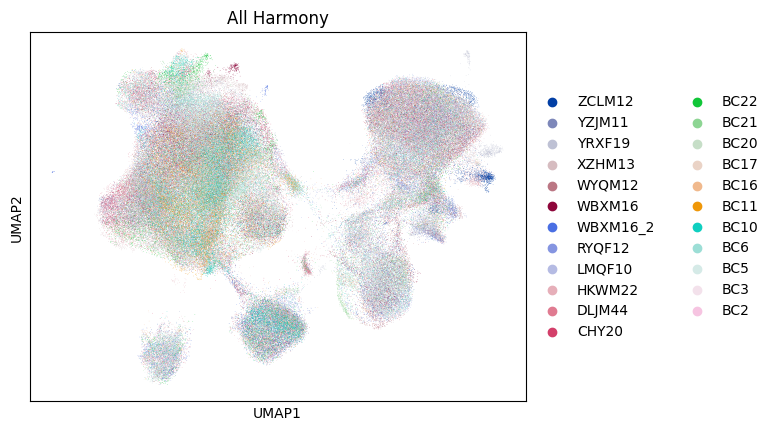

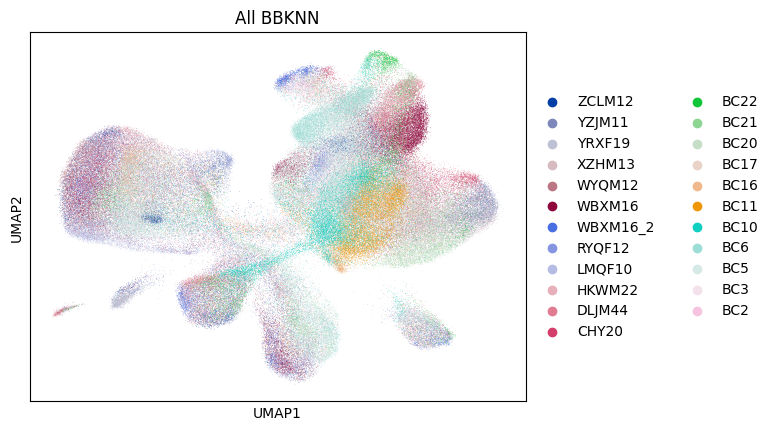

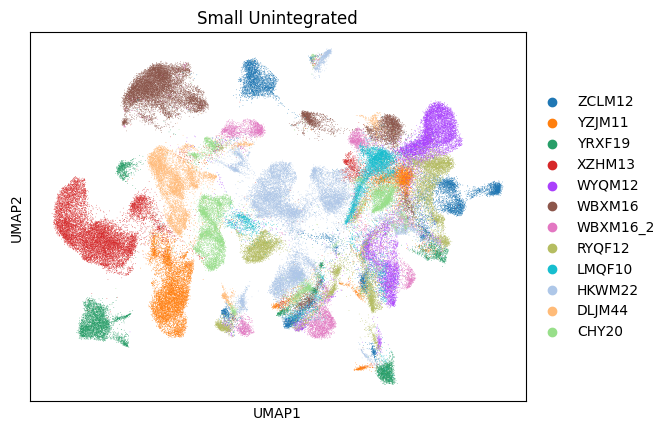

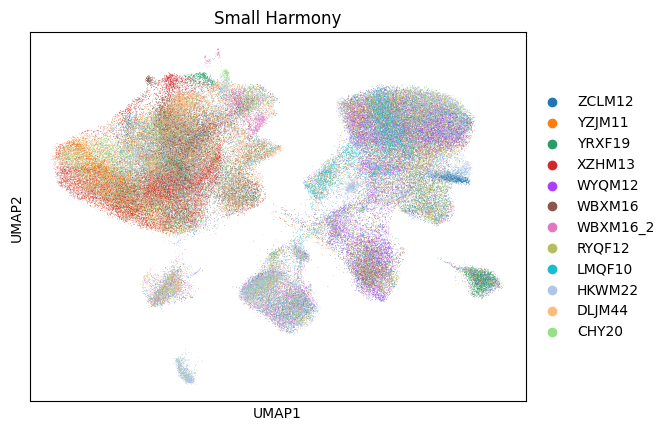

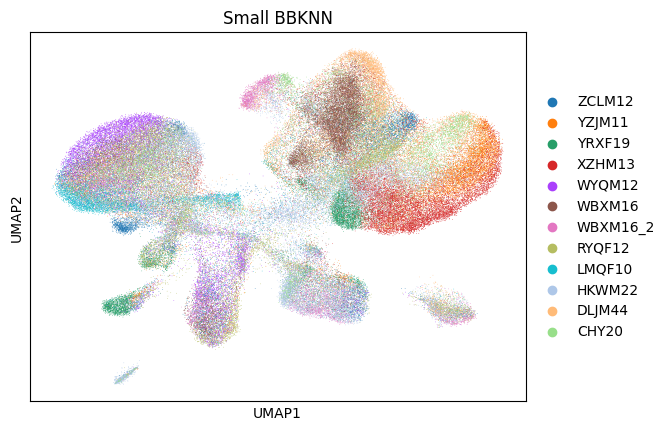

In [9]:
sc.pl.umap(adata_unintegrated, color='sample', title='All Unintegrated')
sc.pl.umap(adata_harmony, color='sample', title='All Harmony')
sc.pl.umap(adata_bbknn, color='sample', title='All BBKNN')
sc.pl.umap(adata_small_unintegrated, color='sample', title='Small Unintegrated')
sc.pl.umap(adata_small_harmony, color='sample', title='Small Harmony')
sc.pl.umap(adata_small_bbknn, color='sample', title='Small BBKNN')

Save

In [10]:
# save
adata_unintegrated.write('%s/all_unintegrated.h5ad' % out_dir)
adata_harmony.write('%s/all_harmony.h5ad' % out_dir)
adata_bbknn.write('%s/all_bbknn.h5ad' % out_dir)
adata_small_unintegrated.write('%s/small_unintegrated.h5ad' % out_dir)
adata_small_harmony.write('%s/small_harmony.h5ad' % out_dir)
adata_small_bbknn.write('%s/small_bbknn.h5ad' % out_dir)